In [98]:
#import dask.dataframe as dd
import pandas as pd
from sklearn.preprocessing import StandardScaler,OneHotEncoder
df = pd.read_csv("/Users/hamzatriki/3ºProyectoDeDatos2/PD2/data/Train/train.csv", delimiter=";")
df

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
0,347259,2025-01-01 11:28:40.463,2025-01-01 11:29:06.856,2025-01-01 11:30:18.069,97.606,Heavy (larger than 136000 kg),-3.572662,40.491829,-3.573822,40.491829,Z3,False,18R/36L,2025-01-01,11
1,abfdd1,2025-01-01 12:53:57.851,2025-01-01 12:54:15.692,2025-01-01 12:55:08.113,70.262,Heavy (larger than 136000 kg),-3.572788,40.491846,-3.573818,40.491858,Z3,False,18R/36L,2025-01-01,12
2,4cacdf,2025-01-01 10:20:25.104,2025-01-01 10:20:38.071,2025-01-01 10:21:24.027,58.923,Medium 2 (between 34000 kg to 136000 kg),-3.561172,40.501179,-3.560085,40.501343,Y3,False,18L/36R,2025-01-01,10
3,34754c,2025-01-01 05:37:49.944,2025-01-01 05:38:03.062,2025-01-01 05:38:52.151,62.207,Medium 2 (between 34000 kg to 136000 kg),-3.576462,40.492481,-3.575488,40.492766,Z4,False,18R/36L,2025-01-01,5
4,34754c,2025-01-01 12:45:58.757,2025-01-01 12:46:16.737,2025-01-01 12:48:41.019,162.262,Medium 2 (between 34000 kg to 136000 kg),-3.576612,40.492475,-3.575519,40.492777,Z4,False,18R/36L,2025-01-01,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44273,4ca8d4,2024-12-26 12:27:51.855,2024-12-26 12:28:20.716,2024-12-26 12:29:38.229,106.374,Medium 2 (between 34000 kg to 136000 kg),-3.561209,40.499504,-3.560148,40.499702,Y1,False,18L/36R,2024-12-26,12
44274,4ca8d4,2024-12-26 19:20:58.493,2024-12-26 19:21:27.415,2024-12-26 19:23:29.475,150.982,Medium 2 (between 34000 kg to 136000 kg),-3.576612,40.492498,-3.575488,40.492754,Z4,False,18R/36L,2024-12-26,19
44275,3c64a8,2024-12-26 06:52:59.064,2024-12-26 06:53:26.693,2024-12-26 06:54:36.374,97.310,Medium 2 (between 34000 kg to 136000 kg),-3.561193,40.500296,-3.560070,40.500470,Y2,False,18L/36R,2024-12-26,6
44276,44cdd1,2024-12-26 16:47:01.673,2024-12-26 16:47:19.837,2024-12-26 16:48:19.333,77.660,Medium 2 (between 34000 kg to 136000 kg),-3.576248,40.491554,-3.575363,40.492081,Z2,False,18R/36L,2024-12-26,16


In [2]:
df = df[df["parado"] == True]
df

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
6,aa5428,2025-01-01 11:58:47.210,2025-01-01 11:59:42.252,2025-01-01 12:01:16.916,149.706,Heavy (larger than 136000 kg),-3.572739,40.491817,-3.573822,40.491817,Z3,True,18R/36L,2025-01-01,12
12,34644c,2025-01-01 10:39:59.985,2025-01-01 10:41:54.188,2025-01-01 10:45:04.579,304.594,Medium 2 (between 34000 kg to 136000 kg),-3.576385,40.491760,-3.575348,40.492081,Z2,True,18R/36L,2025-01-01,10
13,34644c,2025-01-01 18:15:03.927,2025-01-01 18:16:07.879,2025-01-01 18:18:50.910,226.983,Medium 2 (between 34000 kg to 136000 kg),-3.576580,40.492568,-3.575535,40.492836,Z4,True,18R/36L,2025-01-01,18
14,345698,2025-01-01 08:06:24.591,2025-01-01 08:07:28.767,2025-01-01 08:08:32.884,128.293,Medium 2 (between 34000 kg to 136000 kg),-3.561240,40.501262,-3.560054,40.501308,Y3,True,18L/36R,2025-01-01,8
15,345698,2025-01-01 15:24:07.211,2025-01-01 15:25:59.416,2025-01-01 15:27:13.716,186.505,Medium 2 (between 34000 kg to 136000 kg),-3.561193,40.499411,-3.560089,40.499588,Y1,True,18L/36R,2025-01-01,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44256,39de48,2024-12-26 08:18:10.521,2024-12-26 08:19:31.743,2024-12-26 08:20:25.184,134.663,Medium 2 (between 34000 kg to 136000 kg),-3.561234,40.499428,-3.560085,40.499586,Y1,True,18L/36R,2024-12-26,8
44257,39de48,2024-12-26 14:06:38.493,2024-12-26 14:07:28.732,2024-12-26 14:10:34.598,236.105,Medium 2 (between 34000 kg to 136000 kg),-3.561240,40.499423,-3.560089,40.499577,Y1,True,18L/36R,2024-12-26,14
44259,347312,2024-12-26 14:31:14.562,2024-12-26 14:32:26.520,2024-12-26 14:34:03.597,169.035,Medium 2 (between 34000 kg to 136000 kg),-3.561225,40.499423,-3.560101,40.499609,Y1,True,18L/36R,2024-12-26,14
44260,3423c3,2024-12-26 08:58:06.666,2024-12-26 09:00:27.108,2024-12-26 09:01:08.253,181.587,Medium 2 (between 34000 kg to 136000 kg),-3.561234,40.499428,-3.560089,40.499577,Y1,True,18L/36R,2024-12-26,9


In [99]:
df = df.dropna().reset_index(drop=True)

In [100]:
len(df)

43978

In [101]:
## Cargar bien los tiempos
timestap_columns = ["llegada_punto","salida_punto","despegue"]
for col in timestap_columns:
    df[col] = pd.to_datetime(df[col],format="%Y-%m-%d %H:%M:%S.%f")
df["fecha_despegue"] = pd.to_datetime(df["fecha_despegue"],format="%Y-%m-%d")
df.dtypes

ICAO                      object
llegada_punto     datetime64[ns]
salida_punto      datetime64[ns]
despegue          datetime64[ns]
tiempo_espera            float64
aircraft_type             object
llegada_lon              float64
llegada_lat              float64
salida_lon               float64
salida_lat               float64
holding_point             object
parado                      bool
runway                    object
fecha_despegue    datetime64[ns]
hora_despegue              int64
dtype: object

In [102]:
categorical_columns = df.select_dtypes("object")
categorical_columns.columns.drop(["ICAO","holding_point"])

Index(['aircraft_type', 'runway'], dtype='object')

In [103]:
categorical_columns

,ICAO,aircraft_type,holding_point,runway
0,347259,Heavy (larger than 136000 kg),Z3,18R/36L
1,abfdd1,Heavy (larger than 136000 kg),Z3,18R/36L
2,4cacdf,Medium 2 (between 34000 kg to 136000 kg),Y3,18L/36R
3,34754c,Medium 2 (between 34000 kg to 136000 kg),Z4,18R/36L
4,34754c,Medium 2 (between 34000 kg to 136000 kg),Z4,18R/36L
...,...,...,...,...
43973,4ca8d4,Medium 2 (between 34000 kg to 136000 kg),Y1,18L/36R
43974,4ca8d4,Medium 2 (between 34000 kg to 136000 kg),Z4,18R/36L
43975,3c64a8,Medium 2 (between 34000 kg to 136000 kg),Y2,18L/36R
43976,44cdd1,Medium 2 (between 34000 kg to 136000 kg),Z2,18R/36L


In [104]:
encoder = OneHotEncoder(sparse_output=False)

categorical_columns = df.select_dtypes("object").columns.drop(["ICAO","runway"])

encoded_data = encoder.fit_transform(df[categorical_columns])

df_encoded = pd.DataFrame(encoded_data, columns = encoder.get_feature_names_out())
df = df.drop(columns = ["aircraft_type","runway"])
df_encoded = pd.concat([df,df_encoded],axis = 1)

In [105]:
df_encoded.dtypes

ICAO                                                              object
llegada_punto                                             datetime64[ns]
salida_punto                                              datetime64[ns]
despegue                                                  datetime64[ns]
tiempo_espera                                                    float64
llegada_lon                                                      float64
llegada_lat                                                      float64
salida_lon                                                       float64
salida_lat                                                       float64
holding_point                                                     object
parado                                                              bool
fecha_despegue                                            datetime64[ns]
hora_despegue                                                      int64
aircraft_type_Heavy (larger than 136000 kg)        

In [45]:
## datos quitando holding point
"""
encoder = OneHotEncoder(sparse_output=False)

categorical_columns = df.select_dtypes("object").columns.drop(["ICAO","holding_point"])

encoded_data = encoder.fit_transform(df[categorical_columns])

df_encoded = pd.DataFrame(encoded_data, columns = encoder.get_feature_names_out())
df = df.drop(columns = categorical_columns)
df_encoded = pd.concat([df,df_encoded],axis = 1)
"""

'\nencoder = OneHotEncoder(sparse_output=False)\n\ncategorical_columns = df.select_dtypes("object").columns.drop(["ICAO","holding_point"])\n\nencoded_data = encoder.fit_transform(df[categorical_columns])\n\ndf_encoded = pd.DataFrame(encoded_data, columns = encoder.get_feature_names_out())\ndf = df.drop(columns = categorical_columns)\ndf_encoded = pd.concat([df,df_encoded],axis = 1)\n'

In [10]:
df_encoded.head()

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,...,holding_point_LC,holding_point_LE,holding_point_Y1,holding_point_Y2,holding_point_Y3,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6
0,aa5428,2025-01-01 11:58:47.210,2025-01-01 11:59:42.252,2025-01-01 12:01:16.916,149.706,-3.572739,40.491817,-3.573822,40.491817,Z3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,34644c,2025-01-01 10:39:59.985,2025-01-01 10:41:54.188,2025-01-01 10:45:04.579,304.594,-3.576385,40.491760,-3.575348,40.492081,Z2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,34644c,2025-01-01 18:15:03.927,2025-01-01 18:16:07.879,2025-01-01 18:18:50.910,226.983,-3.576580,40.492568,-3.575535,40.492836,Z4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,345698,2025-01-01 08:06:24.591,2025-01-01 08:07:28.767,2025-01-01 08:08:32.884,128.293,-3.561240,40.501262,-3.560054,40.501308,Y3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,345698,2025-01-01 15:24:07.211,2025-01-01 15:25:59.416,2025-01-01 15:27:13.716,186.505,-3.561193,40.499411,-3.560089,40.499588,Y1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [106]:
def calcular_tiempo_relativo(tiempo_referencia,tiempo_fila):
    tiempo_referencia_segundos = tiempo_referencia.timestamp()
    tiempo_fila_segundos = tiempo_fila.timestamp()
    return (tiempo_referencia_segundos - tiempo_fila_segundos)

In [107]:
df_encoded_sorted = df_encoded.sort_values("despegue",ascending = False).reset_index()
df_encoded_sorted

,index,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,llegada_lon,llegada_lat,salida_lon,salida_lat,...,holding_point_LE,holding_point_LF,holding_point_Y1,holding_point_Y2,holding_point_Y3,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6
0,16639,e8044f,2025-01-31 23:46:44.385,2025-01-31 23:47:06.808,2025-01-31 23:48:22.335,97.950,-3.572632,40.491846,-3.573807,40.491840,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,16390,34635a,2025-01-31 23:41:56.653,2025-01-31 23:42:10.920,2025-01-31 23:42:57.914,61.261,-3.576218,40.491520,-3.575363,40.492058,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,16795,346385,2025-01-31 23:29:58.271,2025-01-31 23:30:19.284,2025-01-31 23:32:05.008,126.737,-3.576471,40.491788,-3.575332,40.492079,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,16735,34558f,2025-01-31 23:28:49.943,2025-01-31 23:29:08.720,2025-01-31 23:30:20.798,90.855,-3.576253,40.491509,-3.575333,40.492081,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,16405,347519,2025-01-31 23:25:11.813,2025-01-31 23:26:28.787,2025-01-31 23:28:31.552,199.739,-3.572540,40.490582,-3.573532,40.490971,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43973,17373,346385,2024-11-07 00:11:44.864,2024-11-07 00:12:00.108,2024-11-07 00:12:57.657,72.793,-3.561218,40.499428,-3.560089,40.499577,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
43974,17144,347605,2024-11-07 00:08:59.885,2024-11-07 00:09:16.043,2024-11-07 00:10:51.137,111.252,-3.561234,40.499439,-3.560074,40.499611,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
43975,17297,e80450,2024-11-07 00:07:16.532,2024-11-07 00:07:34.521,2024-11-07 00:08:57.963,101.431,-3.561218,40.499428,-3.560101,40.499597,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
43976,17338,896314,2024-11-07 00:04:57.844,2024-11-07 00:05:20.367,2024-11-07 00:07:06.079,128.235,-3.561218,40.500309,-3.560074,40.500446,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
df_encoded_sorted["tiempo_espera"].describe()

count    13909.000000
mean       283.022624
std       1213.518916
min         25.102000
25%        162.245000
50%        207.838000
75%        282.676000
max      62349.942000
Name: tiempo_espera, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x34703f650>,
 'caps': [<matplotlib.lines.Line2D at 0x3593749b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x3593742c0>],
 'medians': [<matplotlib.lines.Line2D at 0x359374fe0>],
 'fliers': [<matplotlib.lines.Line2D at 0x3593752b0>],
 'means': []}

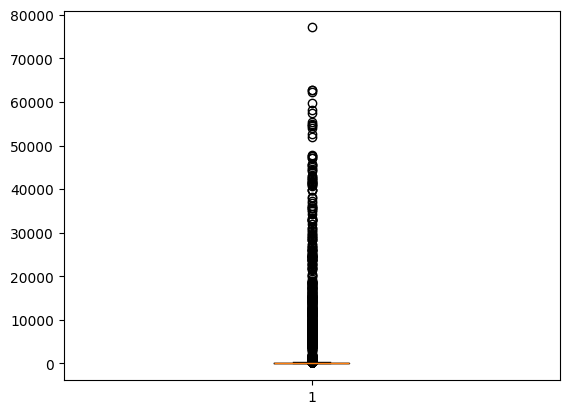

In [108]:
import matplotlib.pyplot as plt

plt.boxplot(df_encoded_sorted["tiempo_espera"])

In [109]:
Q1 = df_encoded_sorted['tiempo_espera'].quantile(0.25)  # Primer cuartil
Q3 = df_encoded_sorted['tiempo_espera'].quantile(0.75)  # Tercer cuartil
IQR = Q3 - Q1  # Rango intercuartílico

# Definir límites para detectar outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar valores dentro de los límites
df_sin_outliers = df_encoded_sorted[(df_encoded_sorted['tiempo_espera'] >= limite_inferior) & (df_encoded_sorted['tiempo_espera'] <= limite_superior)]

print("DataFrame sin outliers:")
print(limite_inferior,limite_superior)
df_sin_outliers.head()

DataFrame sin outliers:
-92.01525000000002 346.25475000000006


,index,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,llegada_lon,llegada_lat,salida_lon,salida_lat,...,holding_point_LE,holding_point_LF,holding_point_Y1,holding_point_Y2,holding_point_Y3,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6
0,16639,e8044f,2025-01-31 23:46:44.385,2025-01-31 23:47:06.808,2025-01-31 23:48:22.335,97.950,-3.572632,40.491846,-3.573807,40.491840,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,16390,34635a,2025-01-31 23:41:56.653,2025-01-31 23:42:10.920,2025-01-31 23:42:57.914,61.261,-3.576218,40.491520,-3.575363,40.492058,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,16795,346385,2025-01-31 23:29:58.271,2025-01-31 23:30:19.284,2025-01-31 23:32:05.008,126.737,-3.576471,40.491788,-3.575332,40.492079,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,16735,34558f,2025-01-31 23:28:49.943,2025-01-31 23:29:08.720,2025-01-31 23:30:20.798,90.855,-3.576253,40.491509,-3.575333,40.492081,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,16405,347519,2025-01-31 23:25:11.813,2025-01-31 23:26:28.787,2025-01-31 23:28:31.552,199.739,-3.572540,40.490582,-3.573532,40.490971,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


<Axes: >

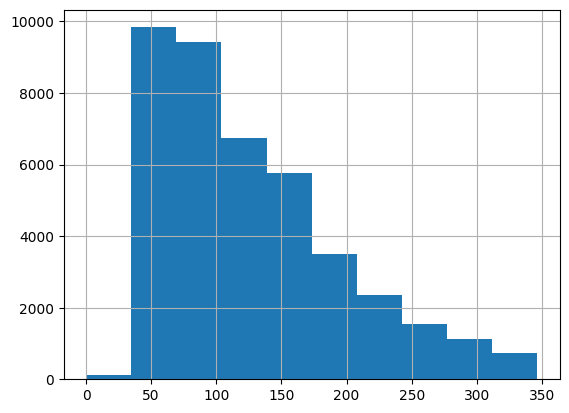

In [110]:
df_sin_outliers["tiempo_espera"].hist()

In [20]:
df_sin_outliers["tiempo_espera"].describe()

count    13858.000000
mean       240.745926
std        118.963031
min         72.234000
25%        162.204500
50%        207.465500
75%        281.900250
max       1156.014000
Name: tiempo_espera, dtype: float64

In [111]:
len(df_sin_outliers)

41165

In [112]:
df_sin_outliers = df_sin_outliers.sort_values(by = "despegue")
df_sin_outliers

,index,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,llegada_lon,llegada_lat,salida_lon,salida_lat,...,holding_point_LE,holding_point_LF,holding_point_Y1,holding_point_Y2,holding_point_Y3,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6
43977,17150,347604,2024-11-07 00:04:12.385,2024-11-07 00:04:27.638,2024-11-07 00:05:24.006,71.621,-3.561209,40.499434,-3.560104,40.499599,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
43976,17338,896314,2024-11-07 00:04:57.844,2024-11-07 00:05:20.367,2024-11-07 00:07:06.079,128.235,-3.561218,40.500309,-3.560074,40.500446,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
43975,17297,e80450,2024-11-07 00:07:16.532,2024-11-07 00:07:34.521,2024-11-07 00:08:57.963,101.431,-3.561218,40.499428,-3.560101,40.499597,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
43974,17144,347605,2024-11-07 00:08:59.885,2024-11-07 00:09:16.043,2024-11-07 00:10:51.137,111.252,-3.561234,40.499439,-3.560074,40.499611,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
43973,17373,346385,2024-11-07 00:11:44.864,2024-11-07 00:12:00.108,2024-11-07 00:12:57.657,72.793,-3.561218,40.499428,-3.560089,40.499577,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,16405,347519,2025-01-31 23:25:11.813,2025-01-31 23:26:28.787,2025-01-31 23:28:31.552,199.739,-3.572540,40.490582,-3.573532,40.490971,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,16735,34558f,2025-01-31 23:28:49.943,2025-01-31 23:29:08.720,2025-01-31 23:30:20.798,90.855,-3.576253,40.491509,-3.575333,40.492081,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,16795,346385,2025-01-31 23:29:58.271,2025-01-31 23:30:19.284,2025-01-31 23:32:05.008,126.737,-3.576471,40.491788,-3.575332,40.492079,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,16390,34635a,2025-01-31 23:41:56.653,2025-01-31 23:42:10.920,2025-01-31 23:42:57.914,61.261,-3.576218,40.491520,-3.575363,40.492058,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [23]:
def saca_puntos_espera(llegada_punto_referencia,holding_referencia,indice,llegada_punto,salida_punto,holding_point):
    ## mira si hay que dropear NA
    if (llegada_punto_referencia >= llegada_punto) and  (salida_punto >= llegada_punto_referencia):
        if holding_referencia !=holding_point:
            return indice,holding_point
        else:
            return indice,None
    else:
        return indice,None 
    

In [78]:
df_sin_outliers = df_sin_outliers.reset_index(drop =True)
print(df_sin_outliers)


       index    ICAO           llegada_punto            salida_punto  \
0       5185  347518 2024-11-07 00:22:11.293 2024-11-07 00:26:28.694   
1       5252  4cac23 2024-11-07 05:02:02.902 2024-11-07 05:06:03.386   
2       5388  484fde 2024-11-07 05:14:26.585 2024-11-07 05:15:36.338   
3       5333  896441 2024-11-07 05:35:39.252 2024-11-07 05:36:26.584   
4       5160  344498 2024-11-07 05:39:04.831 2024-11-07 05:41:53.272   
...      ...     ...                     ...                     ...   
13853   5031  347588 2025-01-31 20:58:19.231 2025-01-31 20:59:18.150   
13854   5085  06a2e9 2025-01-31 21:19:30.275 2025-01-31 21:22:27.896   
13855   5078  344455 2025-01-31 22:08:24.111 2025-01-31 22:09:25.906   
13856   5103  347386 2025-01-31 23:05:58.526 2025-01-31 23:08:51.664   
13857   5003  347519 2025-01-31 23:25:11.813 2025-01-31 23:26:28.787   

                     despegue  tiempo_espera  llegada_lon  llegada_lat  \
0     2024-11-07 00:27:49.530        338.237    -3.561225    

In [114]:
df_sampled = resample_flight_data(df_sin_outliers)
df_sampled

,index,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,llegada_lon,llegada_lat,salida_lon,salida_lat,...,holding_point_LF,holding_point_Y1,holding_point_Y2,holding_point_Y3,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6,tiempo_esperando
43977,17150,347604,2024-11-07 00:04:12.385,2024-11-07 00:04:27.638,2024-11-07 00:05:24.006,71.621,-3.561209,40.499434,-3.560104,40.499599,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
43976,17338,896314,2024-11-07 00:04:57.844,2024-11-07 00:05:20.367,2024-11-07 00:07:06.079,128.235,-3.561218,40.500309,-3.560074,40.500446,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
43975,17297,e80450,2024-11-07 00:07:16.532,2024-11-07 00:07:34.521,2024-11-07 00:08:57.963,101.431,-3.561218,40.499428,-3.560101,40.499597,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
43974,17144,347605,2024-11-07 00:08:59.885,2024-11-07 00:09:16.043,2024-11-07 00:10:51.137,111.252,-3.561234,40.499439,-3.560074,40.499611,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
43973,17373,346385,2024-11-07 00:11:44.864,2024-11-07 00:12:00.108,2024-11-07 00:12:57.657,72.793,-3.561218,40.499428,-3.560089,40.499577,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,16405,347519,2025-01-31 23:25:11.813,2025-01-31 23:26:28.787,2025-01-31 23:28:31.552,139.739,-3.572540,40.490582,-3.573532,40.490971,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,60.0
3,16735,34558f,2025-01-31 23:28:49.943,2025-01-31 23:29:08.720,2025-01-31 23:30:20.798,90.855,-3.576253,40.491509,-3.575333,40.492081,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,16795,346385,2025-01-31 23:29:58.271,2025-01-31 23:30:19.284,2025-01-31 23:32:05.008,126.737,-3.576471,40.491788,-3.575332,40.492079,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,16390,34635a,2025-01-31 23:41:56.653,2025-01-31 23:42:10.920,2025-01-31 23:42:57.914,61.261,-3.576218,40.491520,-3.575363,40.492058,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [113]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

def resample_flight_data(df, interval_seconds=30):
    """
    Resample flight data to create rows at fixed intervals between arrival and departure times.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing flight data with columns 'ICAO', 'llegada_punto', 'salida_punto'
    interval_seconds : int
        Interval in seconds for resampling
        
    Returns:
    --------
    pandas.DataFrame
        Resampled DataFrame with additional rows and tiempo_esperando column
    """
    # Ensure datetime format
    df['llegada_punto'] = pd.to_datetime(df['llegada_punto'])
    df['salida_punto'] = pd.to_datetime(df['salida_punto'])
    
    # Create a list to store the resampled rows
    resampled_rows = []
    
    # For each flight in the original DataFrame
    for _, flight in df.iterrows():
        # Get arrival and departure times
        arrival_time = flight['llegada_punto']
        departure_time = flight['salida_punto']
        tiempo_espera = flight["tiempo_espera"]
        
        # Calculate how many intervals fit between arrival and departure
        time_diff = (departure_time - arrival_time).total_seconds()
        num_intervals = int(time_diff / interval_seconds) + 1
        
        # Create a row for each interval
        for i in range(num_intervals):
            # Calculate the current timestamp
            current_time = arrival_time + timedelta(seconds=i * interval_seconds)
            
            # If we've exceeded the departure time, break
            if current_time > departure_time:
                break
                
            # Create a new row with the original data
            new_row = flight.copy()
            
            # Calculate tiempo_esperando in seconds
            tiempo_esperando = (current_time - arrival_time).total_seconds()
            
            # Add the new column
            new_row['tiempo_esperando'] = tiempo_esperando
            #new_row['timestamp'] = current_time
            new_row["tiempo_espera"] = tiempo_espera -  tiempo_esperando
            
            # Add the row to our collection
            resampled_rows.append(new_row)
    
    # Create a new DataFrame from the resampled rows
    resampled_df = pd.DataFrame(resampled_rows)
    
    return resampled_df

# Example usage:
# resampled_df = resample_flight_data(df)

In [ ]:
lista = []
for i, (index, row) in enumerate(df_sin_outliers.iterrows()):
    if (i -1)>=0:
        llegada_punto_referencia,salida_punto_referencia,despegue,holding_referencia,icao_referencia = row["llegada_punto"],row["salida_punto"],row["despegue"],row["holding_point"],row["ICAO"]
        filtered_df = df_sin_outliers[(df_sin_outliers["llegada_punto"] < llegada_punto_referencia) & (df_sin_outliers["salida_punto"] > llegada_punto_referencia)]
        filtered_df = filtered_df[filtered_df["ICAO"] != icao_referencia]
        lista.append(filtered_df[["index", "holding_point"]].values)

    

In [49]:
lista

[array([], shape=(0, 2), dtype=object),
 array([], shape=(0, 2), dtype=object),
 array([], shape=(0, 2), dtype=object),
 array([], shape=(0, 2), dtype=object),
 array([], shape=(0, 2), dtype=object),
 array([], shape=(0, 2), dtype=object),
 array([[5205, 'Z4']], dtype=object),
 array([], shape=(0, 2), dtype=object),
 array([], shape=(0, 2), dtype=object),
 array([], shape=(0, 2), dtype=object),
 array([], shape=(0, 2), dtype=object),
 array([[5189, 'Y1']], dtype=object),
 array([[5358, 'Z4']], dtype=object),
 array([[5383, 'Y1']], dtype=object),
 array([[5349, 'Z2']], dtype=object),
 array([[5349, 'Z2']], dtype=object),
 array([], shape=(0, 2), dtype=object),
 array([], shape=(0, 2), dtype=object),
 array([], shape=(0, 2), dtype=object),
 array([], shape=(0, 2), dtype=object),
 array([[5298, 'Z2']], dtype=object),
 array([[5154, 'Z4']], dtype=object),
 array([[5241, 'Y2']], dtype=object),
 array([], shape=(0, 2), dtype=object),
 array([], shape=(0, 2), dtype=object),
 array([], shape=(

In [50]:
lista_filtrada = [
    [(idx, val) for idx, val in arr if val is not None]
    for arr in lista[1:] if any(val is not None for _, val in arr)
]


In [51]:
lista_filtrada

[[(5205, 'Z4')],
 [(5189, 'Y1')],
 [(5358, 'Z4')],
 [(5383, 'Y1')],
 [(5349, 'Z2')],
 [(5349, 'Z2')],
 [(5298, 'Z2')],
 [(5154, 'Z4')],
 [(5241, 'Y2')],
 [(5267, 'Z4')],
 [(5216, 'Y2')],
 [(5274, 'Y2')],
 [(5249, 'Y1')],
 [(5274, 'Y2')],
 [(5320, 'Y1')],
 [(5238, 'Y1')],
 [(5227, 'K3')],
 [(5208, 'K2'), (5227, 'K3')],
 [(5273, 'K1'), (5227, 'K3')],
 [(5227, 'K3')],
 [(5337, 'K2')],
 [(5227, 'K3')],
 [(5133, 'K2'), (5396, 'K2')],
 [(5133, 'K2')],
 [(5206, 'K2')],
 [(5323, 'K1')],
 [(5262, 'K1')],
 [(5393, 'K2')],
 [(5262, 'K1')],
 [(5367, 'K1')],
 [(5367, 'K1')],
 [(5299, 'K2')],
 [(5229, 'K1')],
 [(5319, 'K2')],
 [(5265, 'K1')],
 [(5279, 'K2')],
 [(5179, 'K1')],
 [(5143, 'K2')],
 [(5161, 'K1')],
 [(5125, 'K1')],
 [(5222, 'K2')],
 [(5159, 'K1')],
 [(5228, 'K1')],
 [(5228, 'K1')],
 [(5158, 'K2')],
 [(5228, 'K1')],
 [(5141, 'K2'), (5317, 'K1')],
 [(5141, 'K2')],
 [(5343, 'K2'), (5317, 'K1')],
 [(5314, 'K2')],
 [(5174, 'K1')],
 [(5318, 'K1')],
 [(5318, 'K1')],
 [(5318, 'K1')],
 [(5340, 'K2

In [52]:
df_sin_outliers

,index,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,llegada_lon,llegada_lat,salida_lon,salida_lat,...,holding_point_LC,holding_point_LE,holding_point_Y1,holding_point_Y2,holding_point_Y3,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6
0,5185,347518,2024-11-07 00:22:11.293,2024-11-07 00:26:28.694,2024-11-07 00:27:49.530,338.237,-3.561225,40.499423,-3.560089,40.499577,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5252,4cac23,2024-11-07 05:02:02.902,2024-11-07 05:06:03.386,2024-11-07 05:07:29.534,326.632,-3.576614,40.492493,-3.575500,40.492767,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,5388,484fde,2024-11-07 05:14:26.585,2024-11-07 05:15:36.338,2024-11-07 05:18:33.536,246.951,-3.576456,40.491753,-3.575378,40.492081,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,5333,896441,2024-11-07 05:35:39.252,2024-11-07 05:36:26.584,2024-11-07 05:37:34.211,114.959,-3.576614,40.492481,-3.575519,40.492777,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,5160,344498,2024-11-07 05:39:04.831,2024-11-07 05:41:53.272,2024-11-07 05:43:01.991,237.160,-3.576424,40.492486,-3.575488,40.492766,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13853,5031,347588,2025-01-31 20:58:19.231,2025-01-31 20:59:18.150,2025-01-31 21:01:31.838,192.607,-3.576599,40.492481,-3.575485,40.492790,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
13854,5085,06a2e9,2025-01-31 21:19:30.275,2025-01-31 21:22:27.896,2025-01-31 21:23:29.572,239.297,-3.561240,40.499423,-3.560089,40.499611,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13855,5078,344455,2025-01-31 22:08:24.111,2025-01-31 22:09:25.906,2025-01-31 22:10:51.249,147.138,-3.576553,40.492527,-3.575500,40.492767,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
13856,5103,347386,2025-01-31 23:05:58.526,2025-01-31 23:08:51.664,2025-01-31 23:10:39.786,281.260,-3.572617,40.491835,-3.573834,40.491835,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [53]:
from sklearn.cluster import DBSCAN
import numpy as np

# Coordenadas extraídas del GeoJSON
coords = np.array([
    [-3.573093114831562, 40.490653160130186],  # Z1
    [-3.537524367869231, 40.472076292010001],  # KA6
    [-3.536653485337274, 40.466622566754253],  # KA8
    [-3.558959606954449, 40.494122669084419],  # K3
    [-3.559326044131887, 40.4945961819448],    # K2
    [-3.560411408421098, 40.495554592925956],  # K1
    [-3.560656492186808, 40.499431092287409],  # Y1
    [-3.560645785166937, 40.500298406173002],  # Y2
    [-3.560660061193443, 40.501183565039504],  # Y3
    [-3.560800449906033, 40.533391949745102],  # Y7
    [-3.576129307304151, 40.495184843931881],  # Z6
    [-3.576034129003182, 40.492555539298088],  # Z4
    [-3.575903257941006, 40.491865496230126],  # Z2
    [-3.57319305240692, 40.491819096186241],   # Z3
    [-3.572566658955927, 40.479721203031424],  # LF
    [-3.57652786733783, 40.483565816902733],   # L1
    [-3.577181028787666, 40.484251101106899],  # LA
    [-3.577553413710587, 40.484873329796898],  # LB
    [-3.575750378154376, 40.486690643924192],  # LC
    [-3.575150753600524, 40.486522892072891],  # LD
    [-3.574915186586964, 40.485580625293494]   # LE
])

# Convertir a metros
lat_mean = np.deg2rad(40.5)  # Latitud media en radianes
meters_per_lat = 111000
meters_per_lon = 84000  # 111000 * cos(40.5°)
coords_meters = coords * np.array([meters_per_lon, meters_per_lat])

# Aplicar DBSCAN
db = DBSCAN(eps=250, min_samples=1, metric='euclidean').fit(coords_meters)
labels = db.labels_

# Lista de puntos
points = ['Z1', 'KA6', 'KA8', 'K3', 'K2', 'K1', 'Y1', 'Y2', 'Y3', 'Y7', 'Z6', 'Z4', 'Z2', 'Z3', 'LF', 'L1', 'LA', 'LB', 'LC', 'LD', 'LE']

# Crear diccionario
mapping = {points[i]: f'Cluster_{labels[i]}' for i in range(len(points))}
print(mapping)

{'Z1': 'Cluster_0', 'KA6': 'Cluster_1', 'KA8': 'Cluster_2', 'K3': 'Cluster_3', 'K2': 'Cluster_3', 'K1': 'Cluster_3', 'Y1': 'Cluster_4', 'Y2': 'Cluster_4', 'Y3': 'Cluster_4', 'Y7': 'Cluster_5', 'Z6': 'Cluster_6', 'Z4': 'Cluster_0', 'Z2': 'Cluster_0', 'Z3': 'Cluster_0', 'LF': 'Cluster_7', 'L1': 'Cluster_8', 'LA': 'Cluster_8', 'LB': 'Cluster_8', 'LC': 'Cluster_8', 'LD': 'Cluster_8', 'LE': 'Cluster_8'}


In [54]:
mapping

{'Z1': 'Cluster_0',
 'KA6': 'Cluster_1',
 'KA8': 'Cluster_2',
 'K3': 'Cluster_3',
 'K2': 'Cluster_3',
 'K1': 'Cluster_3',
 'Y1': 'Cluster_4',
 'Y2': 'Cluster_4',
 'Y3': 'Cluster_4',
 'Y7': 'Cluster_5',
 'Z6': 'Cluster_6',
 'Z4': 'Cluster_0',
 'Z2': 'Cluster_0',
 'Z3': 'Cluster_0',
 'LF': 'Cluster_7',
 'L1': 'Cluster_8',
 'LA': 'Cluster_8',
 'LB': 'Cluster_8',
 'LC': 'Cluster_8',
 'LD': 'Cluster_8',
 'LE': 'Cluster_8'}

In [55]:
# Procesar lista_filtrada para contar holding points únicos por índice
from collections import defaultdict
holding_points_por_indice = defaultdict(set)
for sublista in lista_filtrada:
    indice = sublista[0][0]  # El índice es el mismo en toda la sublista
    for _, hp in sublista:
        holding_points_por_indice[indice].add(hp)



nuevo_dict = defaultdict(set)
for indice, holdings in holding_points_por_indice.items():
    nuevo_dict[indice] = {mapping[holding] for holding in holdings}

# Convertir a dict normal si lo prefieres
nuevo_dict = dict(nuevo_dict)

# Crear un diccionario con la cantidad de holding points únicos por índice
cantidad_hp_por_indice = {indice: len(hps) for indice, hps in nuevo_dict.items()}

# Añadir la columna 'pistas_ocupadas' al DataFrame
# Suponiendo que df_sin_outliers ya está definido (asegúrate de tenerlo cargado)
import pandas as pd
# Ejemplo: si no lo tienes cargado, descomenta y ajusta esto con tus datos reales
# df_sin_outliers = pd.read_csv('tu_archivo.csv')  

df_sin_outliers['pistas_ocupadas'] = df_sin_outliers['index'].map(cantidad_hp_por_indice).fillna(0).astype(int)

# Mostrar las primeras filas para verificar
print(df_sin_outliers[['index', 'ICAO', 'llegada_punto', 'salida_punto', 'pistas_ocupadas']].head())

   index    ICAO           llegada_punto            salida_punto  \
0   5185  347518 2024-11-07 00:22:11.293 2024-11-07 00:26:28.694   
1   5252  4cac23 2024-11-07 05:02:02.902 2024-11-07 05:06:03.386   
2   5388  484fde 2024-11-07 05:14:26.585 2024-11-07 05:15:36.338   
3   5333  896441 2024-11-07 05:35:39.252 2024-11-07 05:36:26.584   
4   5160  344498 2024-11-07 05:39:04.831 2024-11-07 05:41:53.272   

   pistas_ocupadas  
0                0  
1                0  
2                0  
3                0  
4                0  


In [56]:
df_sin_outliers["pistas_ocupadas"].value_counts()

pistas_ocupadas
0    9263
1    3936
2     659
Name: count, dtype: int64

In [57]:
df_sin_outliers.dtypes

index                                                              int64
ICAO                                                              object
llegada_punto                                             datetime64[ns]
salida_punto                                              datetime64[ns]
despegue                                                  datetime64[ns]
tiempo_espera                                                    float64
llegada_lon                                                      float64
llegada_lat                                                      float64
salida_lon                                                       float64
salida_lat                                                       float64
holding_point                                                     object
parado                                                              bool
fecha_despegue                                            datetime64[ns]
hora_despegue                                      

In [85]:
df_sampled = df_sampled.drop(columns = ["pistas_ocupadas"])
df_sampled

,index,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,llegada_lon,llegada_lat,salida_lon,salida_lat,...,holding_point_Y1,holding_point_Y2,holding_point_Y3,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6,tiempo_esperando,timestamp
0,5185,347518,2024-11-07 00:22:11.293,2024-11-07 00:26:28.694,2024-11-07 00:27:49.530,338.237,-3.561225,40.499423,-3.560089,40.499577,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024-11-07 00:22:11.293
0,5185,347518,2024-11-07 00:22:11.293,2024-11-07 00:26:28.694,2024-11-07 00:27:49.530,338.237,-3.561225,40.499423,-3.560089,40.499577,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,30.0,2024-11-07 00:22:41.293
0,5185,347518,2024-11-07 00:22:11.293,2024-11-07 00:26:28.694,2024-11-07 00:27:49.530,338.237,-3.561225,40.499423,-3.560089,40.499577,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60.0,2024-11-07 00:23:11.293
0,5185,347518,2024-11-07 00:22:11.293,2024-11-07 00:26:28.694,2024-11-07 00:27:49.530,338.237,-3.561225,40.499423,-3.560089,40.499577,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90.0,2024-11-07 00:23:41.293
0,5185,347518,2024-11-07 00:22:11.293,2024-11-07 00:26:28.694,2024-11-07 00:27:49.530,338.237,-3.561225,40.499423,-3.560089,40.499577,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,120.0,2024-11-07 00:24:11.293
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13856,5103,347386,2025-01-31 23:05:58.526,2025-01-31 23:08:51.664,2025-01-31 23:10:39.786,281.260,-3.572617,40.491835,-3.573834,40.491835,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,120.0,2025-01-31 23:07:58.526
13856,5103,347386,2025-01-31 23:05:58.526,2025-01-31 23:08:51.664,2025-01-31 23:10:39.786,281.260,-3.572617,40.491835,-3.573834,40.491835,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,150.0,2025-01-31 23:08:28.526
13857,5003,347519,2025-01-31 23:25:11.813,2025-01-31 23:26:28.787,2025-01-31 23:28:31.552,199.739,-3.572540,40.490582,-3.573532,40.490971,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2025-01-31 23:25:11.813
13857,5003,347519,2025-01-31 23:25:11.813,2025-01-31 23:26:28.787,2025-01-31 23:28:31.552,199.739,-3.572540,40.490582,-3.573532,40.490971,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,30.0,2025-01-31 23:25:41.813


In [115]:
df_sampled

,index,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,llegada_lon,llegada_lat,salida_lon,salida_lat,...,holding_point_LF,holding_point_Y1,holding_point_Y2,holding_point_Y3,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6,tiempo_esperando
43977,17150,347604,2024-11-07 00:04:12.385,2024-11-07 00:04:27.638,2024-11-07 00:05:24.006,71.621,-3.561209,40.499434,-3.560104,40.499599,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
43976,17338,896314,2024-11-07 00:04:57.844,2024-11-07 00:05:20.367,2024-11-07 00:07:06.079,128.235,-3.561218,40.500309,-3.560074,40.500446,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
43975,17297,e80450,2024-11-07 00:07:16.532,2024-11-07 00:07:34.521,2024-11-07 00:08:57.963,101.431,-3.561218,40.499428,-3.560101,40.499597,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
43974,17144,347605,2024-11-07 00:08:59.885,2024-11-07 00:09:16.043,2024-11-07 00:10:51.137,111.252,-3.561234,40.499439,-3.560074,40.499611,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
43973,17373,346385,2024-11-07 00:11:44.864,2024-11-07 00:12:00.108,2024-11-07 00:12:57.657,72.793,-3.561218,40.499428,-3.560089,40.499577,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,16405,347519,2025-01-31 23:25:11.813,2025-01-31 23:26:28.787,2025-01-31 23:28:31.552,139.739,-3.572540,40.490582,-3.573532,40.490971,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,60.0
3,16735,34558f,2025-01-31 23:28:49.943,2025-01-31 23:29:08.720,2025-01-31 23:30:20.798,90.855,-3.576253,40.491509,-3.575333,40.492081,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,16795,346385,2025-01-31 23:29:58.271,2025-01-31 23:30:19.284,2025-01-31 23:32:05.008,126.737,-3.576471,40.491788,-3.575332,40.492079,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,16390,34635a,2025-01-31 23:41:56.653,2025-01-31 23:42:10.920,2025-01-31 23:42:57.914,61.261,-3.576218,40.491520,-3.575363,40.492058,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [89]:
X.columns


Index(['llegada_lon', 'llegada_lat', 'salida_lon', 'salida_lat', 'parado',
       'hora_despegue', 'aircraft_type_Heavy (larger than 136000 kg)',
       'aircraft_type_High vortex aircraft',
       'aircraft_type_Light (less than 7000 kg)',
       'aircraft_type_Medium 1 (between 7000 kg and 34000 kg)',
       'aircraft_type_Medium 2 (between 34000 kg to 136000 kg)',
       'holding_point_K1', 'holding_point_K2', 'holding_point_K3',
       'holding_point_KA6', 'holding_point_KA8', 'holding_point_L1',
       'holding_point_LA', 'holding_point_LB', 'holding_point_LC',
       'holding_point_LE', 'holding_point_Y1', 'holding_point_Y2',
       'holding_point_Y3', 'holding_point_Z1', 'holding_point_Z2',
       'holding_point_Z3', 'holding_point_Z4', 'holding_point_Z6',
       'tiempo_esperando', 'timestamp'],
      dtype='object')

In [95]:
df_sampled

,index,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,llegada_lon,llegada_lat,salida_lon,salida_lat,...,holding_point_Y1,holding_point_Y2,holding_point_Y3,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6,pistas_ocupadas,tiempo_esperando
0,5185,347518,2024-11-07 00:22:11.293,2024-11-07 00:26:28.694,2024-11-07 00:27:49.530,338.237,-3.561225,40.499423,-3.560089,40.499577,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
0,5185,347518,2024-11-07 00:22:11.293,2024-11-07 00:26:28.694,2024-11-07 00:27:49.530,308.237,-3.561225,40.499423,-3.560089,40.499577,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,30.0
0,5185,347518,2024-11-07 00:22:11.293,2024-11-07 00:26:28.694,2024-11-07 00:27:49.530,278.237,-3.561225,40.499423,-3.560089,40.499577,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,60.0
0,5185,347518,2024-11-07 00:22:11.293,2024-11-07 00:26:28.694,2024-11-07 00:27:49.530,248.237,-3.561225,40.499423,-3.560089,40.499577,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,90.0
0,5185,347518,2024-11-07 00:22:11.293,2024-11-07 00:26:28.694,2024-11-07 00:27:49.530,218.237,-3.561225,40.499423,-3.560089,40.499577,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,120.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13856,5103,347386,2025-01-31 23:05:58.526,2025-01-31 23:08:51.664,2025-01-31 23:10:39.786,161.260,-3.572617,40.491835,-3.573834,40.491835,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,120.0
13856,5103,347386,2025-01-31 23:05:58.526,2025-01-31 23:08:51.664,2025-01-31 23:10:39.786,131.260,-3.572617,40.491835,-3.573834,40.491835,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,150.0
13857,5003,347519,2025-01-31 23:25:11.813,2025-01-31 23:26:28.787,2025-01-31 23:28:31.552,199.739,-3.572540,40.490582,-3.573532,40.490971,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0.0
13857,5003,347519,2025-01-31 23:25:11.813,2025-01-31 23:26:28.787,2025-01-31 23:28:31.552,169.739,-3.572540,40.490582,-3.573532,40.490971,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,30.0


In [96]:
X

,llegada_lon,llegada_lat,salida_lon,salida_lat,parado,hora_despegue,aircraft_type_Heavy (larger than 136000 kg),aircraft_type_High vortex aircraft,aircraft_type_Light (less than 7000 kg),aircraft_type_Medium 1 (between 7000 kg and 34000 kg),...,holding_point_Y1,holding_point_Y2,holding_point_Y3,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6,pistas_ocupadas,tiempo_esperando
0,-3.561225,40.499423,-3.560089,40.499577,True,0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
0,-3.561225,40.499423,-3.560089,40.499577,True,0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,30.0
0,-3.561225,40.499423,-3.560089,40.499577,True,0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,60.0
0,-3.561225,40.499423,-3.560089,40.499577,True,0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,90.0
0,-3.561225,40.499423,-3.560089,40.499577,True,0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,120.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13856,-3.572617,40.491835,-3.573834,40.491835,True,23,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,120.0
13856,-3.572617,40.491835,-3.573834,40.491835,True,23,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,150.0
13857,-3.572540,40.490582,-3.573532,40.490971,True,23,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0.0
13857,-3.572540,40.490582,-3.573532,40.490971,True,23,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,30.0


In [119]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
X = df_sampled.drop(columns=["tiempo_espera","index","ICAO","llegada_punto","salida_punto","despegue","fecha_despegue","holding_point","salida_lat","salida_lon","parado","hora_despegue"])
y = df_sampled["tiempo_espera"]

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizar los datos de entrada
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Construcción del modelo
model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1)  # Capa de salida sin activación para regresión
])

# Compilar el modelo
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Configurar Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Entrenar el modelo con Early Stopping
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

# Evaluar el modelo
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f"Error absoluto medio en test: {test_mae:.2f}")


Epoch 1/200


/Users/hamzatriki/3ºProyectoDeDatos2/PD2/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



531/531 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9616.9961 - mae: 76.9976 - val_loss: 3726.9573 - val_mae: 49.0158
Epoch 2/200
531/531 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4717.9277 - mae: 54.0978 - val_loss: 3743.1978 - val_mae: 48.2967
Epoch 3/200
531/531 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4545.3701 - mae: 53.0303 - val_loss: 3663.8706 - val_mae: 48.1042
Epoch 4/200
531/531 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4493.1680 - mae: 52.8166 - val_loss: 3625.5637 - val_mae: 47.8240
Epoch 5/200
531/531 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4444.1060 - mae: 52.5524 - val_loss: 3690.4341 - val_mae: 47.6425
Epoch 6/200
531/531 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4394.7422 - mae: 52.0983 - val_loss: 3748.5625 - val_mae: 47.6684
Epoch 7/200
531/531 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4448.7915 - mae: 52.4569 - val_loss: 3781.7903 - val_mae: 47.5467
Epoch 8/200
531/531 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4343.7417 - mae: 51.7025 - val_loss: 3643.4031 - val_mae: 47.5

In [121]:
y_pred = model.predict(X_test)

531/531 ━━━━━━━━━━━━━━━━━━━━ 0s 372us/step


In [120]:
y_pred = model.predict(X_test)

531/531 ━━━━━━━━━━━━━━━━━━━━ 0s 386us/step


index                                                     1115
ICAO                                                      1115
llegada_punto                                             1115
salida_punto                                              1115
despegue                                                  1115
tiempo_espera                                             1115
llegada_lon                                               1115
llegada_lat                                               1115
salida_lon                                                1115
salida_lat                                                1115
holding_point                                             1115
parado                                                    1115
fecha_despegue                                            1115
hora_despegue                                             1115
aircraft_type_Heavy (larger than 136000 kg)               1115
aircraft_type_High vortex aircraft                     

In [69]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Supongamos que df_sin_outliers ya está definido
X = df_sin_outliers.drop(columns=["tiempo_espera", "index", "ICAO", "llegada_punto", 
                                 "salida_punto", "despegue", "fecha_despegue","holding_point"])
y = df_sin_outliers["tiempo_espera"]

# Dividir en conjuntos de entrenamiento y prueba, conservando los índices
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_test_indices = X_test.index

# Normalizar los datos de entrada
#scaler = StandardScaler()
#X_train = scaler.fit_transform(X_train)
#X_test = scaler.transform(X_test)

# Construcción y entrenamiento del modelo
model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(X_train, y_train, epochs=200, batch_size=128, validation_data=(X_test, y_test))

# Hacer predicciones
y_pred = model.predict(X_test)



Epoch 1/200


/Users/hamzatriki/3ºProyectoDeDatos2/PD2/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 40659.6992 - mae: 158.4442 - val_loss: 14172.0820 - val_mae: 83.8793
Epoch 2/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13475.1484 - mae: 81.6105 - val_loss: 13981.6973 - val_mae: 86.2883
Epoch 3/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13315.0332 - mae: 81.8291 - val_loss: 13490.2666 - val_mae: 81.3787
Epoch 4/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12750.4902 - mae: 79.7081 - val_loss: 13016.5098 - val_mae: 79.4072
Epoch 5/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12882.5518 - mae: 79.8649 - val_loss: 12476.1270 - val_mae: 78.7216
Epoch 6/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11169.7812 - mae: 73.1878 - val_loss: 12043.1504 - val_mae: 75.8532
Epoch 7/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11355.3018 - mae: 73.8328 - val_loss: 11880.7100 - val_mae: 74.6496
Epoch 8/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11855.9697 - mae: 74.9464 - val_loss: 11998.7139 - val_mae: 77.

In [75]:
len(y_pred)

2772

In [125]:
pd.concat([pd.DataFrame(X_test),pd.DataFrame(y_test),pd.DataFrame(y_pred)],axis =1).to_csv("/Users/hamzatriki/3ºProyectoDeDatos2/PD2/data/modelado/y_test_y_pred.csv")

InvalidIndexError: Reindexing only valid with uniquely valued Index objects

In [70]:
# Evaluar el modelo
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f"Error absoluto medio en test: {test_mae:.2f}")

87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 647us/step - loss: 11746.1299 - mae: 73.4529
Error absoluto medio en test: 72.47


In [71]:
# Crear gráfico interactivo con Plotly

results_df = pd.DataFrame({
    'holding_point': df_sin_outliers.loc[X_test_indices, 'holding_point'],
    'real': y_test.values,
    'predicho': y_pred.flatten(),
    'ICAO': df_sin_outliers.loc[X_test_indices, 'ICAO'],
    'llegada_punto': df_sin_outliers.loc[X_test_indices, 'llegada_punto'],
    'salida_punto': df_sin_outliers.loc[X_test_indices, 'salida_punto'],
    'despegue': df_sin_outliers.loc[X_test_indices, 'despegue'],
    'fecha_despegue': df_sin_outliers.loc[X_test_indices, 'fecha_despegue'],
    'pistas_ocupadas':df_sin_outliers.loc[X_test_indices, 'pistas_ocupadas'],
    'parado':df_sin_outliers.loc[X_test_indices,"parado"]
})

fig = go.Figure()

# Añadir trazas para cada holding_point
for point in results_df['holding_point'].unique():
    subset = results_df[results_df['holding_point'] == point]
    fig.add_trace(
        go.Scatter(
            x=subset['real'],
            y=subset['predicho'],
            mode='markers',
            name=point,
            text=[f"ICAO: {row['ICAO']}<br>"
                  f"Holding Point: {row['holding_point']}<br>"
                  f"Real: {row['real']:.2f}<br>"
                  f"Predicho: {row['predicho']:.2f}<br>"
                  f"Llegada: {row['llegada_punto']}<br>"
                  f"Salida: {row['salida_punto']}<br>"
                  f": {row['salida_punto']}<br>"
                  f"Despegue: {row['despegue']}<br>"
                  f"pistas_ocupadas: {row['pistas_ocupadas']}<br>"
                  f"Parado: {row['parado']}<br>"
                  f"Fecha: {row['fecha_despegue']}"
                  for _, row in subset.iterrows()],
            hoverinfo='text',
            visible=True
        )
    )

# Añadir línea de referencia y=x
min_val = min(results_df['real'].min(), results_df['predicho'].min())
max_val = max(results_df['real'].max(), results_df['predicho'].max())
fig.add_trace(
    go.Scatter(
        x=[min_val, max_val],
        y=[min_val, max_val],
        mode='lines',
        line=dict(color='red', dash='dash'),
        name='y=x',
        visible=True
    )
)

# Crear botones para el filtro
buttons = [
    dict(
        label='Todos',
        method='update',
        args=[{'visible': [True] * len(results_df['holding_point'].unique()) + [True]},  # +1 para la línea y=x
              {'title': 'Predicciones vs Valores Reales (Todos los Holding Points)'}]
    )
]

for i, point in enumerate(results_df['holding_point'].unique()):
    visible = [False] * len(results_df['holding_point'].unique())
    visible[i] = True
    buttons.append(
        dict(
            label=point,
            method='update',
            args=[{'visible': visible + [True]},  # +[True] para mantener la línea y=x visible
                  {'title': f'Predicciones vs Valores Reales (Holding Point: {point})'}]
        )
    )

# Actualizar el layout con el dropdown
fig.update_layout(
    title='Predicciones vs Valores Reales por Holding Point',
    xaxis_title='Tiempo de espera real',
    yaxis_title='Tiempo de espera predicho',
    updatemenus=[
        dict(
            buttons=buttons,
            direction='down',
            showactive=True,
            x=0.1,
            xanchor='left',
            y=1.15,
            yanchor='top'
        )
    ],
    showlegend=True,
    hovermode='closest'
)

# Mostrar el gráfico
fig.show()

# Opcional: Gráfico de barras de error por holding_point
error_by_point = results_df.groupby('holding_point').apply(
    lambda x: np.mean(np.abs(x['real'] - x['predicho']))
)

fig_bar = px.bar(
    x=error_by_point.index,
    y=error_by_point.values,
    labels={'x': 'Holding Point', 'y': 'MAE'},
    title='Error Absoluto Medio por Holding Point'
)
fig_bar.update_layout(xaxis={'tickangle': 45})
fig_bar.show()

/var/folders/kf/v4wgzcdn2k5_yn3_h219svlm0000gn/T/ipykernel_68118/4122292666.py:104: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [45]:
results_df

,holding_point,real,predicho,ICAO,llegada_punto,salida_punto,despegue,fecha_despegue
1721,Z2,162.146,101.557541,4ca704,2024-12-04 09:24:21.726,2024-12-04 09:27:03.138,2024-12-04 09:27:03.872,2024-12-04
3252,Z2,144.547,97.194969,347312,2024-12-07 07:03:07.480,2024-12-07 07:05:30.185,2024-12-07 07:05:32.027,2024-12-07
2611,Y1,103.808,181.726028,346047,2024-12-05 21:50:03.968,2024-12-05 21:51:46.921,2024-12-05 21:51:47.776,2024-12-05
1006,Z4,110.629,84.853806,34754c,2024-12-02 20:48:59.115,2024-12-02 20:50:48.617,2024-12-02 20:50:49.744,2024-12-02
3052,Y1,43.498,61.860966,4cadac,2024-12-06 17:11:01.319,2024-12-06 17:11:43.699,2024-12-06 17:11:44.817,2024-12-06
...,...,...,...,...,...,...,...,...
2966,Z2,75.042,114.108948,345251,2024-12-06 14:43:20.166,2024-12-06 14:44:34.083,2024-12-06 14:44:35.208,2024-12-06
2670,Z2,59.055,77.184273,347646,2024-12-06 06:09:54.039,2024-12-06 06:10:52.794,2024-12-06 06:10:53.094,2024-12-06
3450,Z2,193.868,108.742081,346390,2024-12-07 13:34:46.847,2024-12-07 13:38:00.642,2024-12-07 13:38:00.715,2024-12-07
209,Y2,45.334,83.132072,346204,2024-12-01 11:31:43.828,2024-12-01 11:32:28.023,2024-12-01 11:32:29.162,2024-12-01


In [41]:
df_sin_outliers[df_sin_outliers["holding_point"] == "LC"]

,index,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,llegada_lon,llegada_lat,salida_lon,salida_lat,...,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6,runway_14L/32R,runway_14R/32L,runway_18L/36R,runway_18R/36L,pistas_ocupadas
630,887,4951d3,2024-12-02 09:34:39.360,2024-12-02 09:36:46.174,2024-12-02 09:36:53.190,133.830,-3.575790,40.487022,-3.572815,40.481735,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
637,92,781602,2024-12-02 09:39:15.861,2024-12-02 09:44:01.338,2024-12-02 09:44:01.751,285.890,-3.575769,40.487121,-3.571025,40.479976,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
641,182,4d2093,2024-12-02 09:43:50.670,2024-12-02 09:49:04.679,2024-12-02 09:49:06.523,315.853,-3.575800,40.487133,-3.570511,40.479446,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
646,1615,34750a,2024-12-02 09:49:03.789,2024-12-02 09:52:33.293,2024-12-02 09:52:34.983,211.194,-3.575790,40.487103,-3.571625,40.480591,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
647,3125,34750f,2024-12-02 09:50:54.717,2024-12-02 09:53:48.955,2024-12-02 09:53:51.423,176.706,-3.575223,40.486493,-3.571884,40.480831,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
652,250,3472cc,2024-12-02 09:58:26.089,2024-12-02 10:00:26.475,2024-12-02 10:00:28.300,122.211,-3.575790,40.487103,-3.571805,40.480744,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
672,409,3472c9,2024-12-02 10:39:59.725,2024-12-02 10:45:31.176,2024-12-02 10:45:32.921,333.196,-3.575785,40.487051,-3.571426,40.480350,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
676,1426,34644e,2024-12-02 10:48:37.081,2024-12-02 10:50:59.529,2024-12-02 10:51:02.928,145.847,-3.575816,40.487110,-3.572055,40.481011,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
678,3474,3451d8,2024-12-02 10:50:21.369,2024-12-02 10:53:12.095,2024-12-02 10:53:15.317,173.948,-3.575287,40.486416,-3.571758,40.480697,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
680,3797,3420cc,2024-12-02 10:53:46.943,2024-12-02 10:56:43.990,2024-12-02 10:56:45.733,178.790,-3.575238,40.486481,-3.572159,40.481094,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0


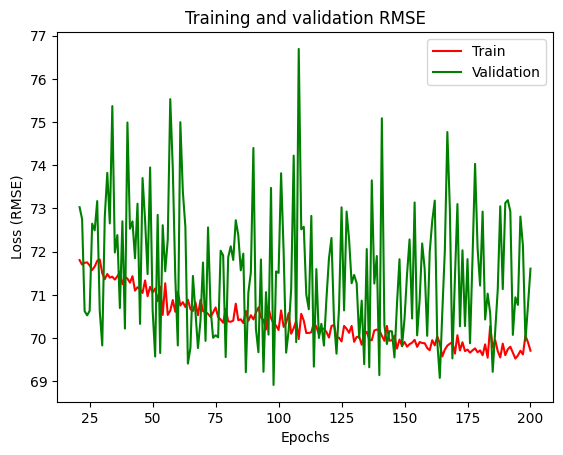

In [68]:
import matplotlib.pyplot as plt

loss = history.history['mae']
val_loss = history.history['val_mae']

epochs = range(1, len(loss) + 1)

plt.plot(epochs[20:], loss[20:], 'r', label='Train')
plt.plot(epochs[20:], val_loss[20:], 'g', label='Validation')

plt.title('Training and validation RMSE')
plt.xlabel('Epochs')
plt.ylabel('Loss (RMSE)')
plt.legend()

plt.show()

In [13]:
df_lista = []
for indice, fila in df_encoded_sorted.iterrows():
    if indice < len(df_encoded_sorted) - 1:  # Verificar que no sea el último índice
        tiempo_referencia = fila["despegue"]
        
        # Seleccionar solo las filas a partir del índice
        tiempos= df_encoded_sorted.iloc[indice:].apply(
            lambda row: calcular_tiempo_relativo(tiempo_referencia, row["despegue"]), axis=1)
        
        # Filtrar el DataFrame en función de la columna 'ventana'
        ##df_filter = df_encoded_sorted[(df_encoded_sorted["ventana"] <= 1800)]
    
        tiempos = tiempos[tiempos <=1800]
   
        df_concat = pd.concat([df_encoded_sorted.iloc[indice: indice + len(tiempos)],tiempos],axis =1)
        df_lista.append(df_concat)


In [20]:
df_lista[16]

,index,ICAO,ultimo_parado,despegue,tiempo_espera,lat,lon,fecha_despegue,hora_despegue,aircraft_type_Heavy (larger than 136000 kg),...,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6,runway_14L/32R,runway_14R/32L,runway_18L/36R,runway_18R/36L,runway_nan,0
16,1294,4d22b1,2024-12-07 19:23:06.400,2024-12-07 19:25:05.533,119.133,40.505672,-3.559243,2024-12-07,19,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000
17,378,346082,2024-12-07 19:22:52.903,2024-12-07 19:24:28.367,95.464,40.495846,-3.574646,2024-12-07,19,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,37.166
18,1049,3472c9,2024-12-07 19:21:22.609,2024-12-07 19:22:57.972,95.363,40.497448,-3.574677,2024-12-07,19,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,127.561
19,918,3451da,2024-12-07 19:19:28.541,2024-12-07 19:21:34.394,125.853,40.497723,-3.574646,2024-12-07,19,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,211.139
20,214,347648,2024-12-07 19:18:11.059,2024-12-07 19:19:54.912,103.853,40.494358,-3.574631,2024-12-07,19,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,310.621
21,604,3451d9,2024-12-07 19:03:19.564,2024-12-07 19:04:42.408,82.844,40.499222,-3.574661,2024-12-07,19,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1223.125
22,467,345698,2024-12-07 18:58:30.030,2024-12-07 19:02:17.756,227.726,40.499474,-3.574661,2024-12-07,19,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1367.777
23,649,344216,2024-12-07 18:57:21.751,2024-12-07 19:00:47.118,205.367,40.499817,-3.574692,2024-12-07,19,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1458.415


In [244]:
for i, df in enumerate(df_lista):
    df.to_csv(f"/Users/hamzatriki/3ºProyectoDeDatos2/PD2/data/modelado/dataframe_{i}.csv", index=False)